Vertices:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

Edges:
[(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4), (3, 5), (4, 6), (5, 6), (5, 7), (5, 8), (6, 7), (6, 8), (7, 8), (7, 9), (8, 10), (9, 10), (9, 11), (9, 12), (10, 11), (10, 12), (11, 12)]

Adjacency List:
1: [2, 3, 4]
2: [1, 3, 4]
3: [1, 2, 4, 5]
4: [1, 2, 3, 6]
5: [3, 6, 7, 8]
6: [4, 5, 7, 8]
7: [5, 6, 8, 9]
8: [5, 6, 7, 10]
9: [7, 10, 11, 12]
10: [8, 9, 11, 12]
11: [9, 10, 12]
12: [9, 10, 11]

Adjacency Matrix:
[[0 1 1 1 0 0 0 0 0 0 0 0]
 [1 0 1 1 0 0 0 0 0 0 0 0]
 [1 1 0 1 1 0 0 0 0 0 0 0]
 [1 1 1 0 0 1 0 0 0 0 0 0]
 [0 0 1 0 0 1 1 1 0 0 0 0]
 [0 0 0 1 1 0 1 1 0 0 0 0]
 [0 0 0 0 1 1 0 1 1 0 0 0]
 [0 0 0 0 1 1 1 0 0 1 0 0]
 [0 0 0 0 0 0 1 0 0 1 1 1]
 [0 0 0 0 0 0 0 1 1 0 1 1]
 [0 0 0 0 0 0 0 0 1 1 0 1]
 [0 0 0 0 0 0 0 0 1 1 1 0]]

Incidence Matrix:
Columns correspond to edges:
[(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4), (3, 5), (4, 6), (5, 6), (5, 7), (5, 8), (6, 7), (6, 8), (7, 8), (7, 9), (8, 10), (9, 10), (9, 11), (9, 1

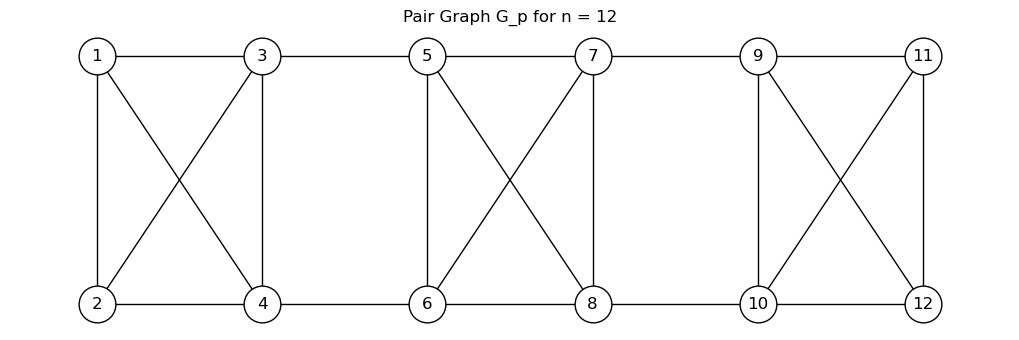

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


def build_pair_graph(n):
    if n <= 0 or n % 2 != 0:
        raise ValueError("n must be a positive even integer.")

    G = nx.Graph()
    G.add_nodes_from(range(1, n + 1))
    m = n // 2

    for k in range(1, m + 1):
        G.add_edge(2 * k - 1, 2 * k)

    for k in range(1, m):
        top_left = 2 * k - 1
        bottom_left = 2 * k
        top_right = 2 * k + 1
        bottom_right = 2 * k + 2

        G.add_edge(top_left, top_right)
        G.add_edge(bottom_left, bottom_right)

        if k % 2 == 1:
            G.add_edge(top_left, bottom_right)
            G.add_edge(bottom_left, top_right)

    edges = sorted(tuple(sorted(e)) for e in G.edges())
    return G, edges


def adjacency_list(G):
    return {node: sorted(list(G.neighbors(node))) for node in G.nodes()}


def adjacency_matrix(G):
    nodes = sorted(G.nodes())
    index = {node: i for i, node in enumerate(nodes)}
    n = len(nodes)
    A = np.zeros((n, n), dtype=int)

    for u, v in G.edges():
        i, j = index[u], index[v]
        A[i, j] = 1
        A[j, i] = 1

    return A


def incidence_matrix(G):
    nodes = sorted(G.nodes())
    edges = sorted(tuple(sorted(e)) for e in G.edges())
    node_index = {node: i for i, node in enumerate(nodes)}
    I = np.zeros((len(nodes), len(edges)), dtype=int)

    for j, (u, v) in enumerate(edges):
        I[node_index[u], j] = 1
        I[node_index[v], j] = 1

    return I, edges


def pair_graph_positions(n):
    pos = {}
    m = n // 2
    for k in range(1, m + 1):
        pos[2 * k - 1] = (k, 1)
        pos[2 * k] = (k, 0)
    return pos


def plot_pair_graph(G, n, title="Pair Graph G_p"):
    pos = pair_graph_positions(n)

    plt.figure(figsize=(10, 3))
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=700,
        node_color="white",
        edgecolors="black"
    )
    plt.title(title)
    plt.axis("off")
    plt.show()


# ----- Test -----
n = 12
G, edges = build_pair_graph(n)

print("Vertices:")
print(list(G.nodes()))

print("\nEdges:")
print(edges)

print("\nAdjacency List:")
L = adjacency_list(G)
for node, neighbors in L.items():
    print(f"{node}: {neighbors}")

print("\nAdjacency Matrix:")
A = adjacency_matrix(G)
print(A)

print("\nIncidence Matrix:")
I, edge_columns = incidence_matrix(G)
print("Columns correspond to edges:")
print(edge_columns)
print(I)

plot_pair_graph(G, n, title="Pair Graph G_p for n = 12")